In [10]:
#Trabajo Final – Lenguajes 2025: Análisis de datos con el dataset TMDB 5000 Movies
##Integrante: Testa Fiorella, Rocha Milagros.  

In [11]:
##Descripción general del dataset

#En este trabajo se analiza el dataset TMDB 5000 Movies, que tiene información detallada sobre películas: presupuesto, recaudación, géneros, etc.  
#El objetivo del análisis es obtener una visión general del comportamiento del rating, el presupuesto, el ROI y la influencia de los directores, a partir de un procesamiento de los datos.

#A lo largo del notebook se realiza la carga, limpieza, preparación y análisis de los datos, incluyendo visualizaciones y generación de archivos finales en formato CSV. 
#Todas las tareas se desarrollan utilizando Python y las librerías: pandas, numpy, matplotlib, seaborn y ast.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set(style="whitegrid", rc={"figure.figsize": (11, 6)})

def convertir_json(texto):
    try:
        return ast.literal_eval(texto)
    except:
        return []

# Cargar datasets
peliculas = pd.read_csv("datos/tmdb_5000_movies.csv")
creditos = pd.read_csv("datos/tmdb_5000_credits.csv")

df = peliculas.merge(creditos, left_on="id", right_on="movie_id", how="inner")

ModuleNotFoundError: No module named 'numpy'

In [ ]:
#Fuente del dataset: kaggle - “TMDB 5000 Movie Dataset”

In [ ]:
## Vista general inicial del dataset

print("Primeras filas de 'peliculas':")
display(peliculas.head())

print("\nInformación general de 'peliculas':")
display(peliculas.info())

print("\nCantidad de nulos por columna en 'peliculas':")
display(peliculas.isnull().sum())

print("\nPrimeras filas de 'creditos':")
display(creditos.head())

print("\nInformación general de 'creditos':")
display(creditos.info())

print("\nCantidad de nulos por columna en 'creditos':")
display(creditos.isnull().sum())


Primeras filas de 'peliculas':


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124



Información general de 'peliculas':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null

None


Cantidad de nulos por columna en 'peliculas':


...

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."



Información general de 'creditos':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4803 non-null   int64 
 1   title     4803 non-null   object
 2   cast      4803 non-null   object
 3   crew      4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB


None


Cantidad de nulos por columna en 'creditos':


movie_id    0
title       0
cast        0
crew        0
dtype: int64

In [ ]:
# Inspección inicial del dataset

#Se identificaron nulos y tipos incorrectos en varias columnas.
#Varias columnas JSON venían como texto (genres, cast, crew).
#Había budgets y revenues en 0, y faltantes en runtime y release_date.


In [ ]:
## Limpieza y preparación 
#En esta parte se preparo los datos para el análisis:

# Se convirtieron las columnas que vienen como texto pero representan listas/diccionarios (`genres`, `cast`, `crew`, etc.) usando una función auxiliar.
# Se transformo la fecha de estreno a formato datetime y se creo una columna de año.
# Se convirtio `runtime` y `vote_average` a valores numéricos.
# Se filtro las películas que tienen presupuesto y recaudación mayores a 0.
# Se calculo el indicador `ROI = revenue / budget`, que se usa más adelante en el análisis.


In [ ]:
columnas_json_peliculas = ["genres", "keywords", "production_countries", "production_companies"]
for col in columnas_json_peliculas:
    peliculas[col] = peliculas[col].apply(convertir_json)

columnas_json_creditos = ["cast", "crew"]
for col in columnas_json_creditos:
    creditos[col] = creditos[col].apply(convertir_json)

peliculas["release_date"] = pd.to_datetime(peliculas["release_date"], errors="coerce")
peliculas["año"] = peliculas["release_date"].dt.year

peliculas = peliculas[(peliculas["budget"] > 0) & (peliculas["revenue"] > 0)]

peliculas["ROI"] = peliculas["revenue"] / peliculas["budget"]
peliculas["rating"] = pd.to_numeric(peliculas["vote_average"], errors="coerce")
peliculas["runtime"] = pd.to_numeric(peliculas["runtime"], errors="coerce")

print("Filas procesadas:", peliculas.shape)


Filas procesadas: (3229, 23)


In [ ]:
##Lo siguiente es un desarrollo de cuatro ejes de análisis que responden preguntas sobre el dataset. Cada eje incluye gráficos.

##Eje 1 — Rating promedio por rango de presupuesto
#En este eje se agrupan las películas por rangos de presupuesto (en millones de dólares) y se calcula el rating promedio de cada grupo.  

/var/folders/sf/xfvctmbj5fxbtvhfzjz49x0h0000gn/T/ipykernel_69605/1511222024.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_por_presupuesto = df_eje1.groupby("rango_presupuesto")["rating"].mean().reset_index()
/var/folders/sf/xfvctmbj5fxbtvhfzjz49x0h0000gn/T/ipykernel_69605/1511222024.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rating_por_presupuesto, x="rango_presupuesto", y="rating", palette="viridis")


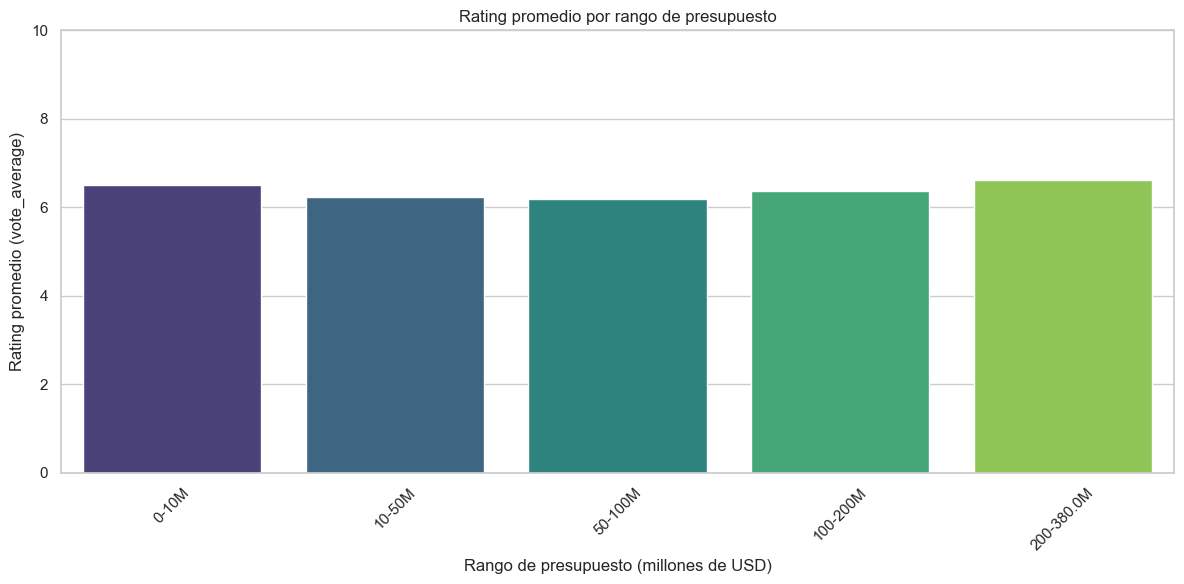

In [ ]:
# ======================================================
# EJE 1 — Rating promedio por rango de presupuesto
# ======================================================

df_eje1 = peliculas[["budget","rating"]].dropna()
df_eje1 = df_eje1[df_eje1["budget"] > 0].copy()
df_eje1["budget_millones"] = df_eje1["budget"] / 1_000_000

max_budget = df_eje1["budget_millones"].max()

# construir bins sin romper el orden
bins = [0, 10, 50, 100, 200, 500, 1000]
bins = [b for b in bins if b < max_budget]
bins.append(max_budget)

labels = [f"{bins[i]}-{bins[i+1]}M" for i in range(len(bins)-1)]

df_eje1["rango_presupuesto"] = pd.cut(df_eje1["budget_millones"], bins=bins, labels=labels, include_lowest=True)

rating_por_presupuesto = df_eje1.groupby("rango_presupuesto")["rating"].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=rating_por_presupuesto, x="rango_presupuesto", y="rating", palette="viridis")
plt.title("Rating promedio por rango de presupuesto")
plt.xlabel("Rango de presupuesto (millones de USD)")
plt.ylabel("Rating promedio (vote_average)")
plt.xticks(rotation=45)
plt.ylim(0, 10)
plt.tight_layout()
plt.savefig("grafico_presupuesto_vs_rating.png")
plt.show()

rating_por_presupuesto.to_csv("result_presupuesto_vs_rating.csv", index=False)
 

In [ ]:
#Comentario Eje 1: Los rangos con presupuestos altos muestran ratings más estables y concentrados. En los presupuestos bajos hay más diversidad: aparecen tanto películas buen como mal valoradas. No se ve una relación lineal, pero sí menos variabilidad en los extremos altos.

In [ ]:
## Eje 2 — Duración mediana por década (últimos 50 años): 
# en este eje se tomo las películas de los últimos 50 años y se agrupo por década. Para cada década se calcula la duración mediana, para ver si con el tiempo las películas se fueron alargando, acortando o si se mantienen más o menos en un mismo rango.


Duración por década:
   decada        mean  median  count
0  1970.0  118.818182   118.0     44
1  1980.0  111.450980   107.0    204
2  1990.0  112.677778   108.0    540
3  2000.0  108.632959   105.0   1335
4  2010.0  109.463569   107.0    947


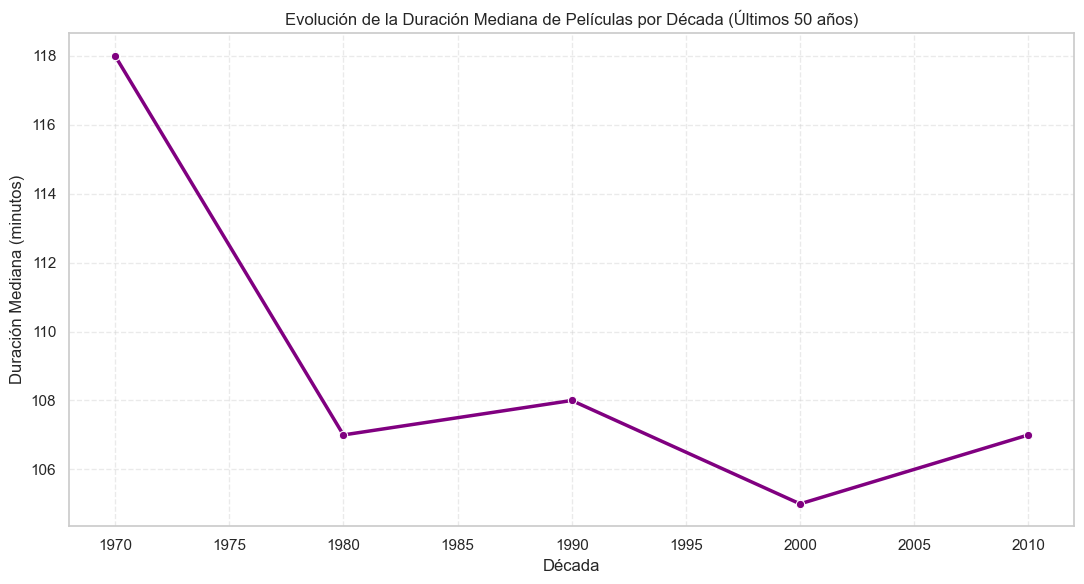

In [ ]:
# ======================================================
# EJE 2 — Duración mediana por década (últimos 50 años)
# ======================================================

current_year = 2025
start_year = current_year - 50

df_eje2 = peliculas.dropna(subset=["año", "runtime"])
df_eje2 = df_eje2[(df_eje2["año"] >= start_year) & (df_eje2["año"] <= current_year)]

df_eje2["decada"] = (df_eje2["año"] // 10) * 10
duracion_por_decada = df_eje2.groupby("decada")["runtime"].agg(["mean", "median", "count"]).reset_index()

print("\nDuración por década:")
print(duracion_por_decada)

plt.figure(figsize=(11, 6))
sns.lineplot(
    data=duracion_por_decada,
    x="decada",
    y="median",
    marker="o",
    linewidth=2.5,
    color="purple"
)
plt.title("Evolución de la Duración Mediana de Películas por Década (Últimos 50 años)")
plt.xlabel("Década")
plt.ylabel("Duración Mediana (minutos)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("grafico_duracion_por_decada.png")
plt.show()

duracion_por_decada.to_csv("result_duracion_por_decada.csv", index=False)


In [ ]:
##Comentario Eje 2: la duración mediana por década cambia un poco, pero no hay saltos extremos. En general, las películas se mantienen dentro de un rango similar de minutos, lo que muestra estabilidad a lo largo de las décadas.


In [ ]:
# EJE 3 — ROI promedio por género: en este eje se uso el ROI calculado arriba y se expandieron los géneros para obtener un promedio de ROI para cada categoría.


ROI promedio por género:
             genero          ROI
3            Comedy  7663.066247
6             Drama  5908.024215
11           Horror  3077.422678
16         Thriller  1074.897187
5       Documentary   160.106742
13          Mystery    67.761837
12            Music     6.435301
2         Animation     6.087650
15  Science Fiction     5.926710
8           Fantasy     5.817778
7            Family     5.157520
14          Romance     5.089232
18          Western     4.901748
17              War     4.899900
1         Adventure     4.458006
4             Crime     4.238685
10          History     4.042294
0            Action     3.579040
9           Foreign     0.460747


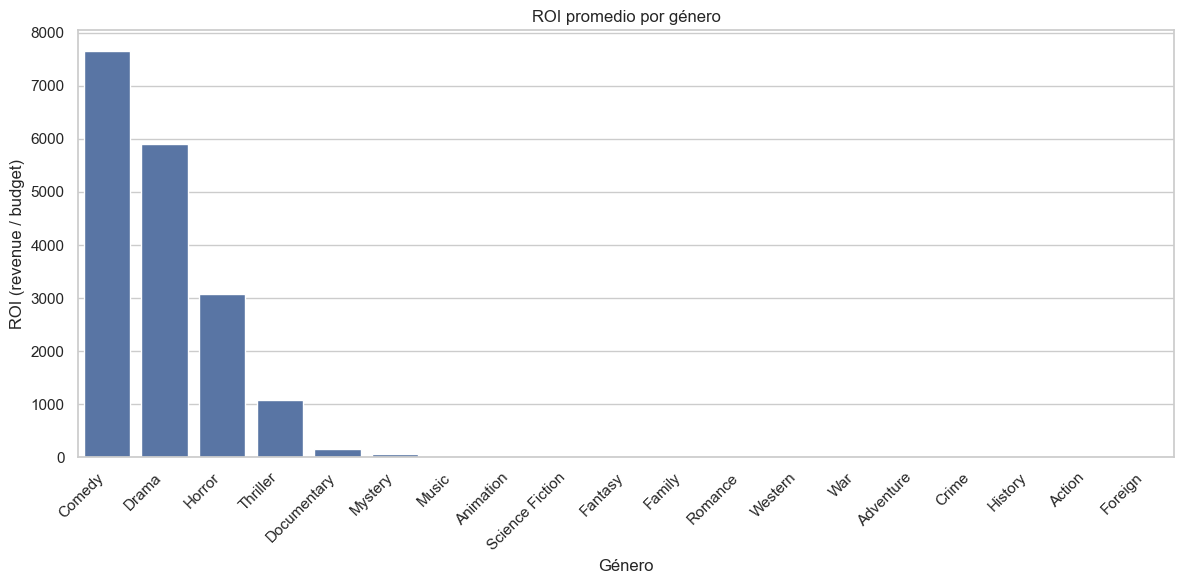

In [ ]:
# ======================================================
# EJE 3 — ROI promedio por género
# ======================================================

df_eje3 = peliculas[["title", "genres", "ROI"]].dropna(subset=["ROI"]).copy()

filas_genero = []

for indice, fila in df_eje3.iterrows():
    generos = fila["genres"]

    if not generos:
        continue

    for genero in generos:
        nombre_genero = genero.get("name")

        filas_genero.append({
            "titulo": fila["title"],
            "genero": nombre_genero,
            "ROI": fila["ROI"]
        })

df_roi_genero = pd.DataFrame(filas_genero)

df_roi_genero = df_roi_genero.dropna(subset=["genero"])

roi_por_genero = df_roi_genero.groupby("genero")["ROI"].mean().reset_index()

roi_por_genero = roi_por_genero.sort_values("ROI", ascending=False)

print("\nROI promedio por género:")
print(roi_por_genero)

plt.figure(figsize=(12, 6))
sns.barplot(data=roi_por_genero, x="genero", y="ROI")
plt.title("ROI promedio por género")
plt.xlabel("Género")
plt.ylabel("ROI (revenue / budget)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("grafico_roi_por_genero.png")
plt.show()

roi_por_genero.to_csv("result_roi_por_genero.csv", index=False)


In [ ]:
#Comentario Eje 3: Al ordenar los géneros por ROI promedio se ve que algunos logran un rendimiento mucho más alto que otros. En general, los géneros con buenos resultados combinan presupuestos moderados con películas que funcionaron bien en taquilla, lo que mejora el ratio de retorno.


In [ ]:
# Eje 4 — Directores con mejor rating promedio: en este eje se identifican a los directores a partir de la columna `crew` del archivo de créditos y se relaciona esa información con el rating de sus películas. Después se calcula el rating promedio de cada director y se filtra solo los que tienen al menos 3 películas, para que la comparación sea más justa.



Directores con mejor rating promedio (mínimo 3 películas):
               director  rating_promedio  cantidad_peliculas
556      Hayao Miyazaki         8.050000                   4
1353       Sergio Leone         7.933333                   3
136        Billy Wilder         7.833333                   3
238   Christopher Nolan         7.800000                   8
1153        Pete Docter         7.733333                   3
1386    Stanley Kubrick         7.683333                   6
356    Denis Villeneuve         7.666667                   3
1052       Miloš Forman         7.633333                   3
454         Frank Capra         7.620000                   5
1198  Quentin Tarantino         7.550000                  10
456      Frank Darabont         7.500000                   4
411          Elia Kazan         7.466667                   3
322          David Lean         7.450000                   4
1179         Peter Weir         7.450000                   4
1226     Richard Brooks  

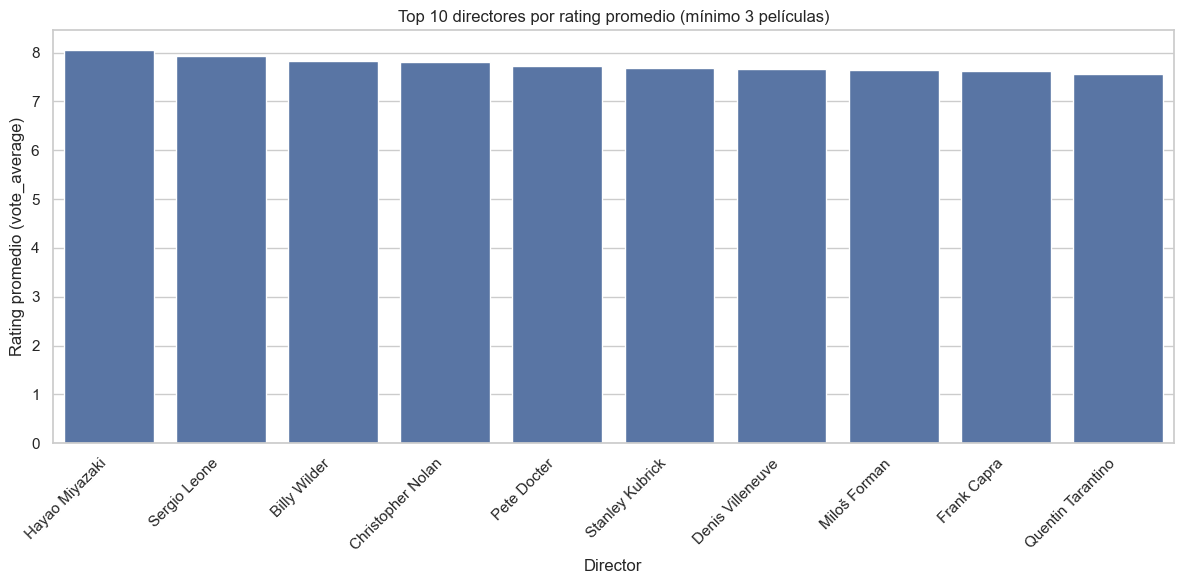

In [ ]:
# ======================================================
# EJE 4 — Directores con mejor rating promedio (mínimo 3 películas)
# ======================================================

df_eje4_creditos = creditos[["movie_id", "crew"]].copy()

filas_directores = []

for indice, fila in df_eje4_creditos.iterrows():
    movie_id = fila["movie_id"]
    crew = fila["crew"]

    for persona in crew:
        if persona.get("job") == "Director":
            filas_directores.append({
                "movie_id": movie_id,
                "director": persona.get("name")
            })

df_directores = pd.DataFrame(filas_directores)

df_pelis_rating = peliculas[["id", "title", "rating"]].dropna(subset=["rating"])

directores_peliculas = df_directores.merge(
    df_pelis_rating,
    left_on="movie_id",
    right_on="id",
    how="left"
)

directores_peliculas = directores_peliculas.dropna(subset=["rating"])

resumen_directores = directores_peliculas.groupby("director")["rating"].agg(["mean", "count"]).reset_index()
resumen_directores = resumen_directores.rename(columns={
    "mean": "rating_promedio",
    "count": "cantidad_peliculas"
})

resumen_directores = resumen_directores[resumen_directores["cantidad_peliculas"] >= 3]

resumen_directores = resumen_directores.sort_values(
    ["rating_promedio", "cantidad_peliculas"],
    ascending=False
)

print("\nDirectores con mejor rating promedio (mínimo 3 películas):")
print(resumen_directores.head(20))

top10_directores = resumen_directores.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_directores, x="director", y="rating_promedio")
plt.title("Top 10 directores por rating promedio (mínimo 3 películas)")
plt.xlabel("Director")
plt.ylabel("Rating promedio (vote_average)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("grafico_directores_rating.png")
plt.show()

resumen_directores.to_csv("result_directores_rating.csv", index=False)


In [ ]:
#Comentario Eje 4: El ranking final muestra a los directores que mantienen buenos promedios de rating con varias películas en el dataset. Esto me deja identificar nombres que son relativamente consistentes en términos de valoración del público.


In [ ]:
##Generación de archivos '.csv' y gráficos para la API

#Los resultados de cada eje se exportan en archivos '.csv':

#- result_presupuesto_vs_rating.csv
#- result_duracion_por_decada.csv
#- result_roi_por_genero.csv
#- result_directores_rating.csv

#Todos los gráficos se guardan en formato `.png`:

#- grafico_presupuesto_vs_rating.png
#- grafico_duracion_por_decada.png
#- grafico_roi_por_genero.png
#- grafico_directores_rating.png


In [ ]:
print("\nCSV generados:")
print("result_presupuesto_vs_rating.csv")
print("result_duracion_por_decada.csv")
print("result_roi_por_genero.csv")
print("result_directores_rating.csv")

print("PNG generados:")
print("grafico_presupuesto_vs_rating.png")
print("grafico_duracion_por_decada.png")
print("grafico_roi_por_genero.png")
print("grafico_directores_rating.png")


CSV generados:
result_presupuesto_vs_rating.csv
result_duracion_por_decada.csv
result_roi_por_genero.csv
result_directores_rating.csv
PNG generados:
grafico_presupuesto_vs_rating.png
grafico_duracion_por_decada.png
grafico_roi_por_genero.png
grafico_directores_rating.png
